# Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import xgboost as xgb
from sklearn.metrics import mean_squared_error
plt.style.use('seaborn-v0_8-dark')
color_pal = sns.color_palette()

In [2]:
df = pd.read_csv('IVE.csv')
df.head()

,FechaProcedimiento,Cantidad
0,2023-04-01 00:00:00.000,27
1,2023-04-03 00:00:00.000,37
2,2023-04-04 00:00:00.000,38
3,2023-04-05 00:00:00.000,45
4,2023-04-11 00:00:00.000,49


In [3]:
df['FechaProcedimiento'] =  pd.to_datetime(df['FechaProcedimiento'])
df = df.set_index('FechaProcedimiento')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751 entries, 2023-04-01 to 2025-11-04
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Cantidad  751 non-null    int64
dtypes: int64(1)
memory usage: 11.7 KB


In [4]:
np.round(df.describe(),2)

,Cantidad
count,751.00
mean,33.71
std,10.25
min,1.00
25%,28.00
50%,33.00
75%,40.00
max,82.00


<Axes: title={'center': 'IVE realizados bajo escafandra'}, xlabel='FechaProcedimiento'>

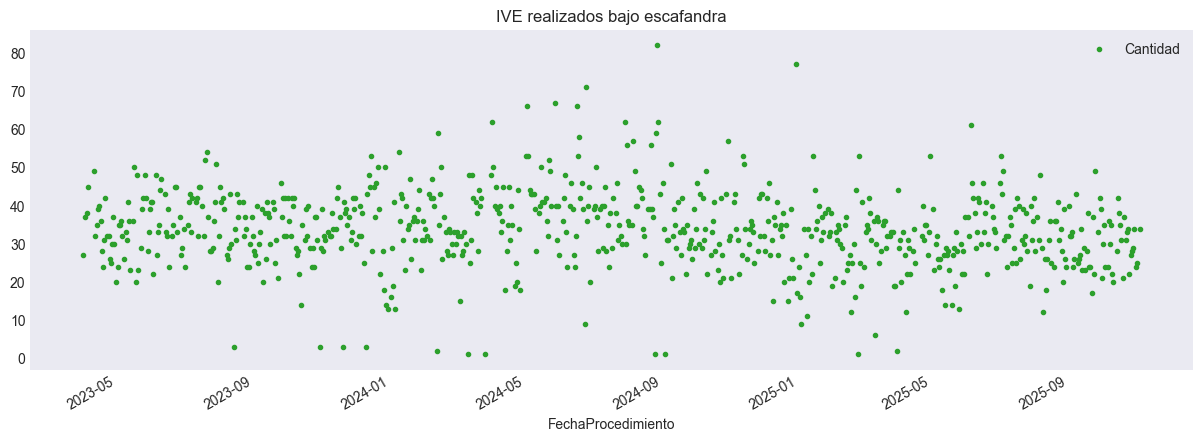

In [5]:
df.plot(style = '.', figsize=(15,5), title="IVE realizados bajo escafandra", color = color_pal[2])

<Axes: title={'center': 'Una Semana de datos'}, xlabel='FechaProcedimiento'>

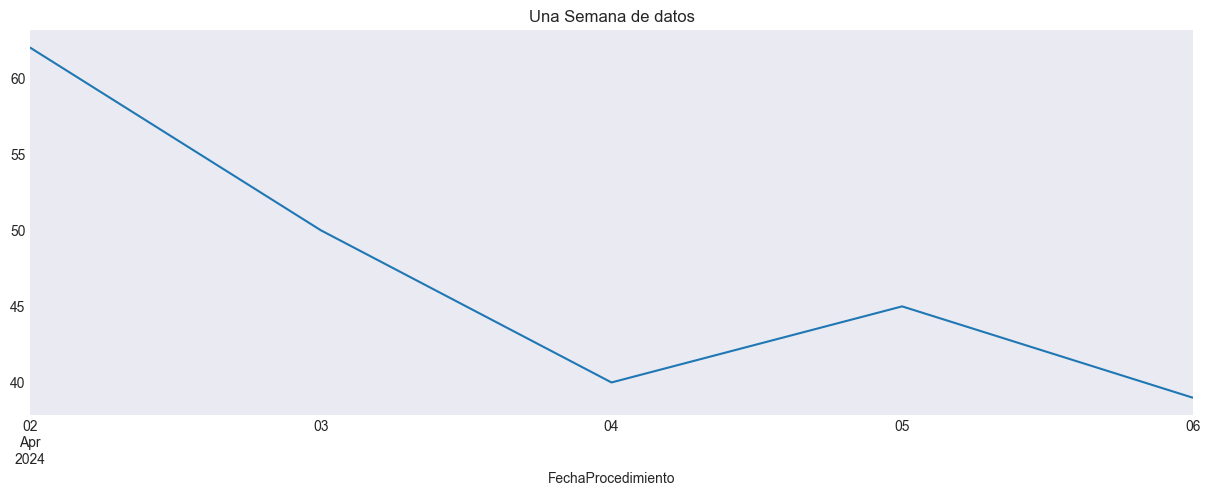

In [6]:
df.loc[(df.index > '2024-04-01') & (df.index < '2024-04-07')]['Cantidad'] \
    .plot(figsize=(15,5), title="Una Semana de datos")

# Train / Test Split

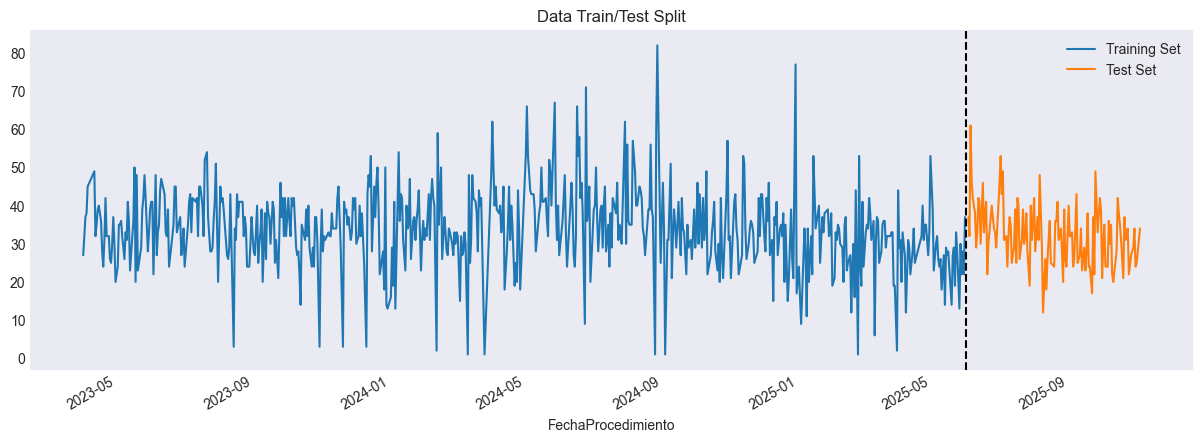

In [7]:
train = df.loc[df.index < '2025-06-01']
test = df.loc[df.index >= '2025-06-01']

fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label='Training Set', title="Data Train/Test Split")
test.plot(ax=ax, label='Test Set')
ax.axvline('2025-06-01', color='black',ls='--')
ax.legend(['Training Set','Test Set'])
plt.show()

In [8]:
def create_features(df):
    '''
    Create time series features based on time series index
    '''
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year 
    df['dayofyear'] = df.index.dayofyear
    return df 

df = create_features(df)

In [9]:
df.head(5)

,Cantidad,dayofweek,quarter,month,year,dayofyear
FechaProcedimiento,,,,,,
2023-04-01,27,5,2,4,2023,91
2023-04-03,37,0,2,4,2023,93
2023-04-04,38,1,2,4,2023,94
2023-04-05,45,2,2,4,2023,95
2023-04-11,49,1,2,4,2023,101


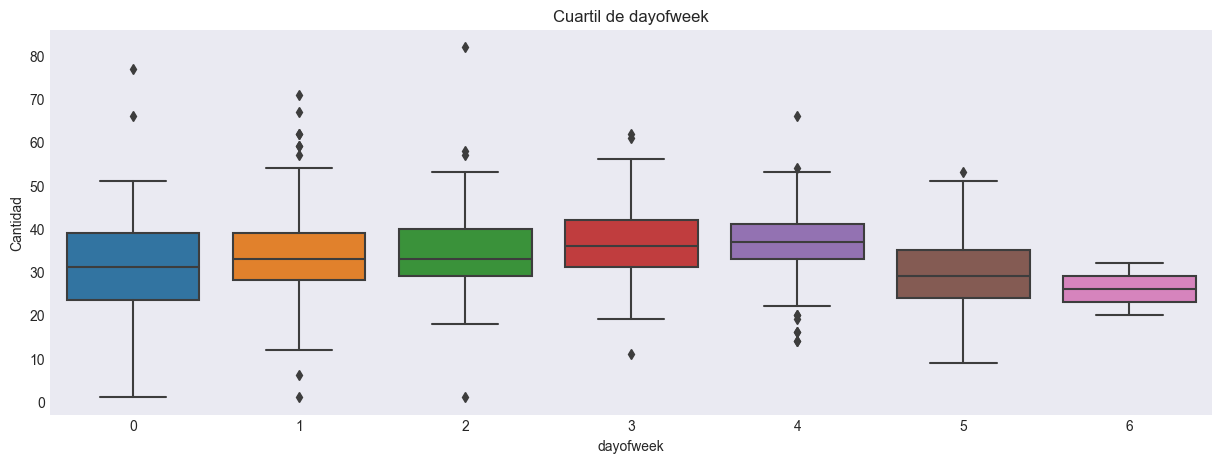

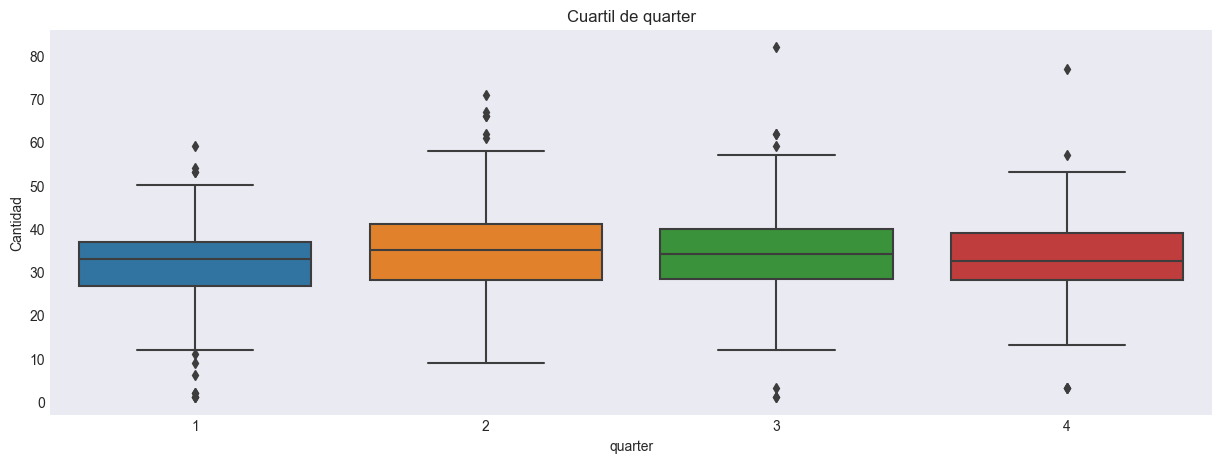

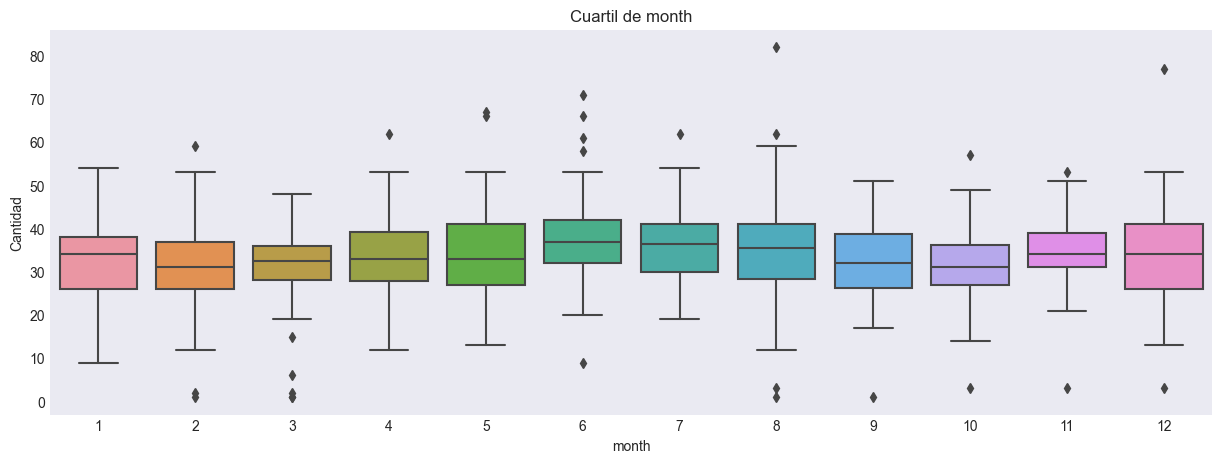

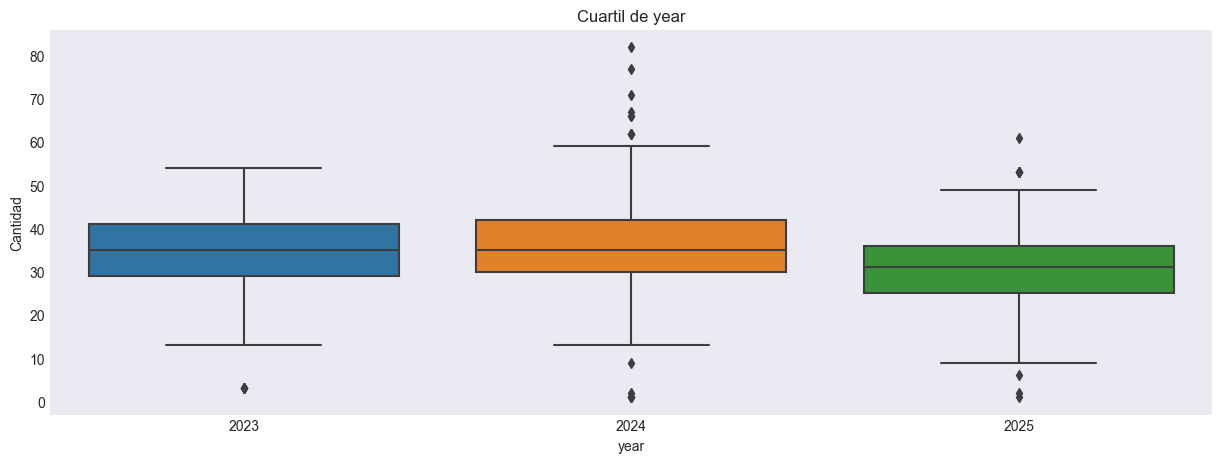

In [10]:
columns = ['dayofweek','quarter','month','year']

for i,column in enumerate(columns, 1):
    plt.figure(figsize=(15,5))
    fig = sns.boxplot(data=df, x=column, y='Cantidad')
    plt.title(f'Cuartil de {column}')
    plt.show()

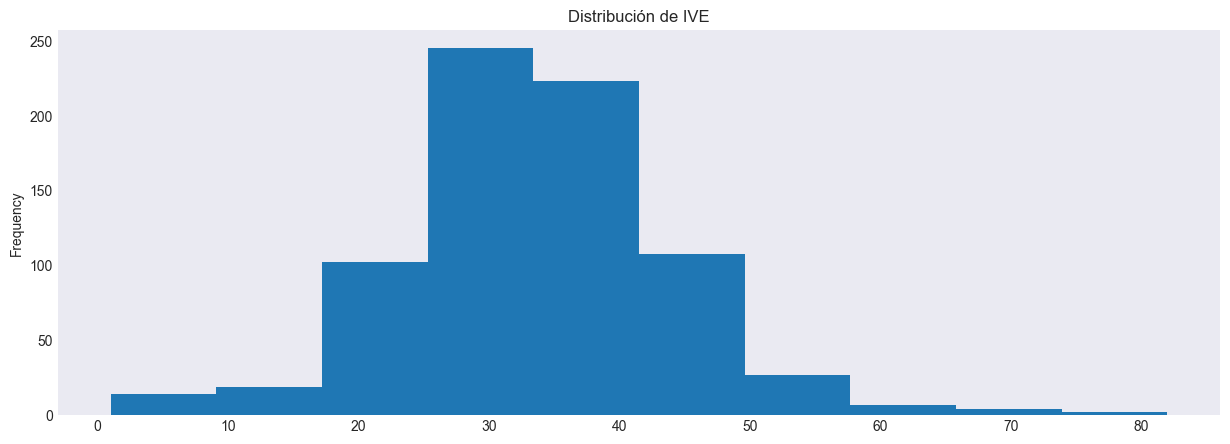

In [11]:
plt.figure(figsize=(15,5))
df['Cantidad'].plot(kind='hist', title="Distribución de IVE")
plt.show()

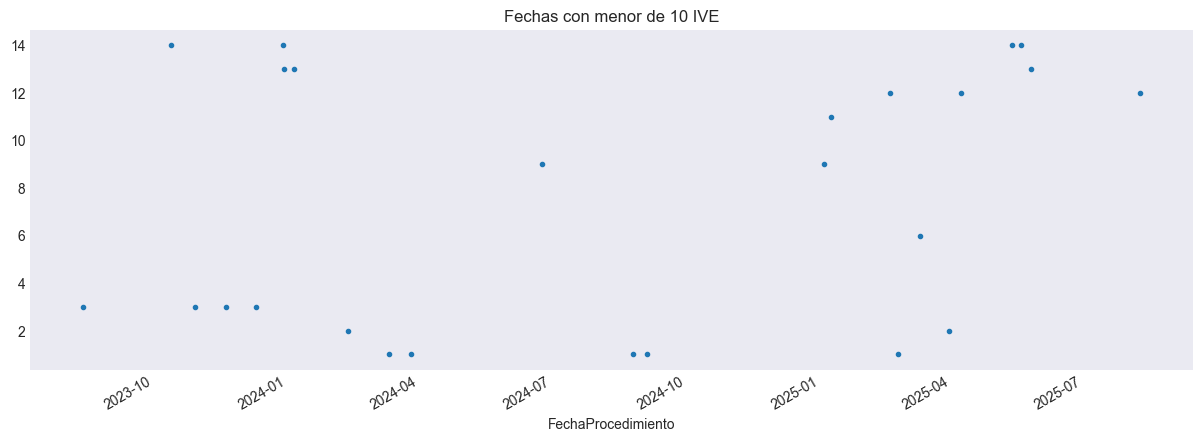

In [12]:
menor10 = df.query('Cantidad < 15')

menor10['Cantidad'].plot(style='.', figsize=(15,5),title="Fechas con menor de 10 IVE")
plt.show()

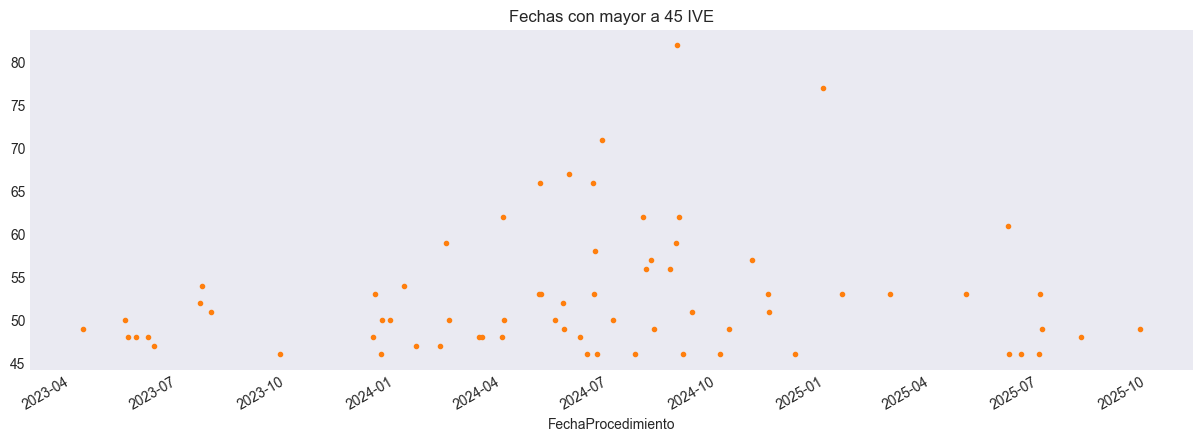

In [13]:
menor10 = df.query('Cantidad > 45')

menor10['Cantidad'].plot(style='.', figsize=(15,5),title="Fechas con mayor a 45 IVE", color=color_pal[1])
plt.show()

# Create a Model with XGBoost

In [14]:
train.tail()

,Cantidad
FechaProcedimiento,
2025-05-27,30
2025-05-28,22
2025-05-29,28
2025-05-30,22
2025-05-31,37


In [15]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'Cantidad'

In [16]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [17]:
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,
                       learning_rate=0.1)
reg.fit(X_train,y_train,
        eval_set=[(X_train, y_train),(X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:10.32044	validation_1-rmse:8.19321
[92]	validation_0-rmse:5.45379	validation_1-rmse:8.54704


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Feature Importance

In [18]:
fi = pd.DataFrame(data=reg.feature_importances_,
                  index=reg.feature_names_in_,
                  columns=['importance'])

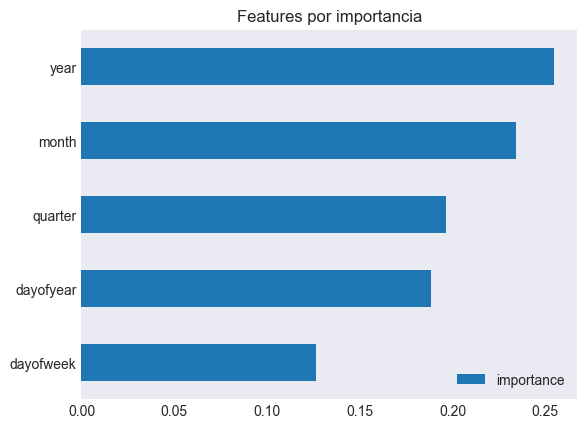

In [19]:
fi.sort_values('importance').plot(kind='barh', title='Features por importancia')
plt.show()

## Forecast on Test

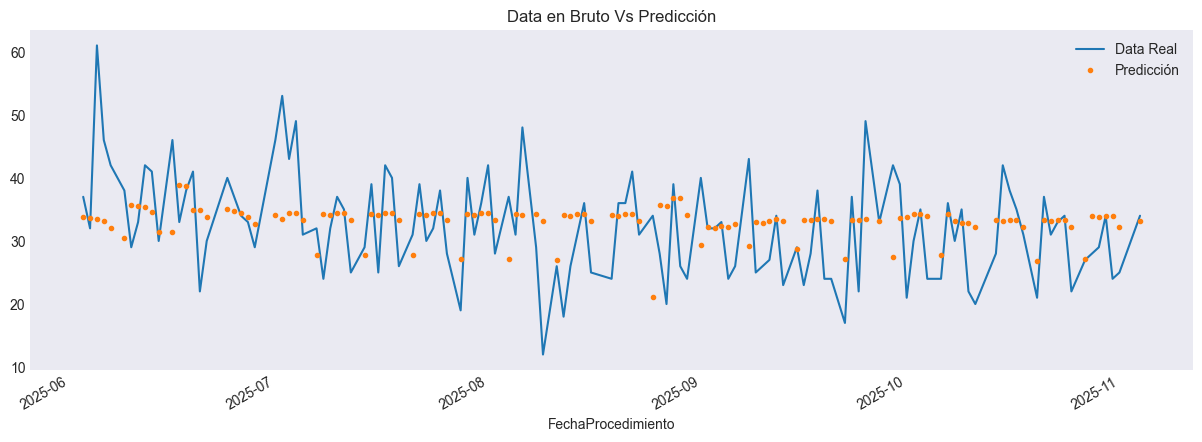

In [20]:
test['prediction'] = reg.predict(X_test)

df = df.merge(test[['prediction']], left_index=True, right_index=True)
ax = df[['Cantidad']].plot(figsize=(15,5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(["Data Real", "Predicción"])
ax.set_title("Data en Bruto Vs Predicción")
plt.show()

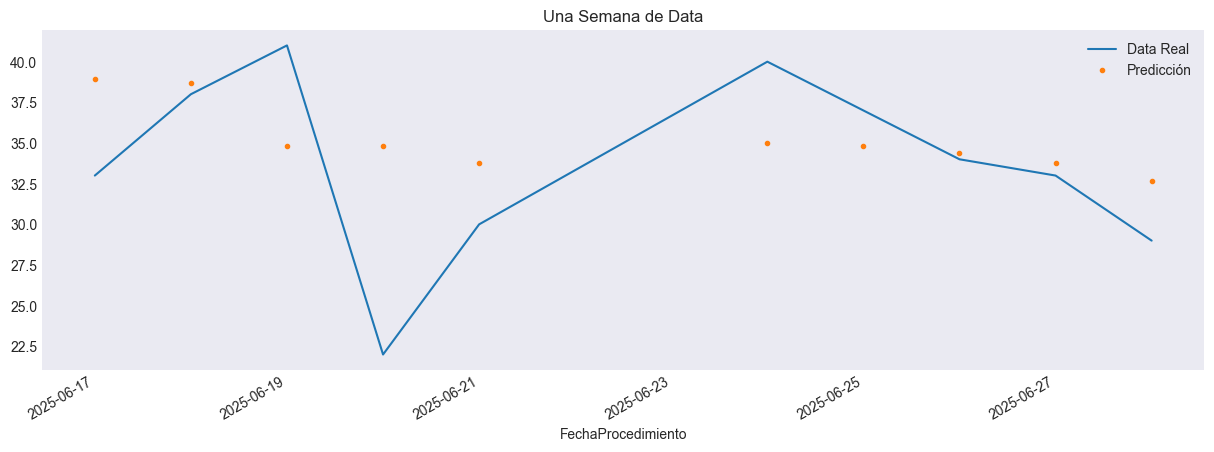

In [23]:
ax = df.loc[(df.index > '2025-06-16') & (df.index < '2025-06-29')]['Cantidad'] \
    .plot(figsize=(15,5), title="Una Semana de Data")
df.loc[(df.index > '2025-06-16') & (df.index < '2025-06-29')]['prediction'] \
    .plot(style='.')
plt.legend(["Data Real", "Predicción"])
plt.show()

In [24]:
score = np.sqrt(mean_squared_error(test['Cantidad'], test['prediction']))
print(f'RMSE Score on test set: {score:0.2f}')

RMSE Score on test set: 8.04


In [25]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Modelo baseline (predice la media)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_baseline = dummy.predict(X_test)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f"Tu modelo: {8.04}")
print(f"Modelo baseline (media): {rmse_baseline:.2f}")

if 8.04 < rmse_baseline:
    print("✅ Tu modelo es mejor que predecir siempre la media")
else:
    print("❌ Tu modelo no aprende patrones útiles")

Tu modelo: 8.04
Modelo baseline (media): 8.16
✅ Tu modelo es mejor que predecir siempre la media
